# 4 ピーク検出 (個別)

# SEDアノマリ評価、有意度評価起点
# --- TO DO ---
### Goodness of fit
  - Investigation of the fitted function parameters  -> Done

### Resisual Distribution: Check (Is it a Gaussian?)
 - K-S test
(sensitive to mode )
 - Anderson Darling
(Sensitive to tail)
### Resisual Distribution: Maybe a heat map?


### Grant result


# --- 実データ適用編：評価 ---

## 各SEDのbin数
### -> 重みづけ込みの確率算出
異なるbin数による確率の違いをテーブルにする。
各bin数で理論・計算での整合性を確認する。
実際のSEDは各々異なるbin数なので、確率テーブルを使って重みづけ計算する。



## 各データ点の residual vs.energy 分布
### -> そのまま
### -> 上限を揃えたらどうなる？


## chi2 vs. fitted parameter
Hardな方がフィットしづらくなったり？










# --- 実データ適用編：異常発見 ---
## Sudden drop

## LEでの急減少


# --- コード開発 ---
## Probability table generation

14 bins from 9 to 22


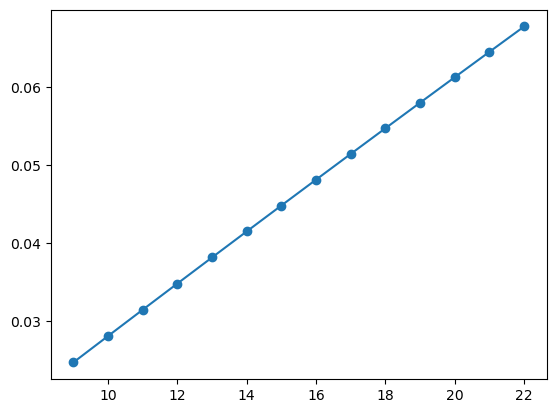

In [11]:
import numpy as np
# p=(1-0.95)/2.0
nbinsmin=9
nbinsmax=22
p=(1-0.68)/2.0
P=np.array([[1-p,p,0,0],[1-p,0,p,0],[1-p,0,0,p],[0,0,0,1]])
A=np.matrix(P)
probs = []
for ibins in range(nbinsmin, nbinsmax+1):
  B=A**ibins
  probs.append(B[0,3])

print(len(probs), "bins from", nbinsmin, "to", nbinsmax)
import matplotlib.pyplot as plt
plt.plot(range(nbinsmin, nbinsmax+1), probs, marker='o')


## - Utility functions
### Peak detection
### Gaussian
### Red.Chisq. calculation
### plotSED

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u
from scipy.optimize import curve_fit


###################
# Peak detection
###################
nconsecutive = 3
def get_consecutive_bins(s,nconsecutive ):

  for i in range(0,len(s)-nconsecutive+1):
  # for i in range(0,len(s)-nconsecutive):
      if np.all(s[i:i+nconsecutive] > 1.0):
        #   print(i)
        #   print(s[i:i+nconsecutive])
        #   print('---')
          return i
      
  return -1

###################
# Utility functions
###################
def gaussian(x, amplitude, mu, sigma):
    # return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2) : Normal distribution
    return amplitude * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def calc_reduced_chi_square(fit, x, y, yerr, N, n_free):
    '''
    fit (array) values for the fit
    x,y,yerr (arrays) data
    N total number of points
    n_free number of parameters we are fitting
    '''
    return 1.0/(N-n_free)*sum(((fit - y)/yerr)**2)

def plotSED(x, y, yerr, fitted_line, peakbininit, nconsecutive, residuals,reduced_chi_squared, obsdate, idx, sourcename=""):
   # Plot the SED with the fitted line, with the residual plot at the bottom
  fig = plt.figure(figsize=(10, 6))
  frame1=fig.add_axes((.1,.3,.8,.6))
  plt.errorbar(x, y, yerr=yerr, marker='o', linestyle='', label='Data')
  plt.plot(x, fitted_line(x), '-', label='Fitted Line')
  plt.plot(x[peakbininit:peakbininit+nconsecutive],
           y[peakbininit:peakbininit+nconsecutive], label='Peak Region', marker='x', linestyle='-')
  # plt.title(f"Observation {idx}: MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  # plt.title(f"GB6J1040+0617 : MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.title(f"{sourcename} : MJD {round(obsdate,3)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.xlabel('Energy [MeV]')
  plt.ylabel(r"E$^2d\phi/d$E [MeV/cm$^{-2}$ s$^{-1}$]")
  plt.xscale('log')
  plt.yscale('log')
  # plt.xlim(100, 3e3)
  # plt.ylim(1e-2, 2) # for GB6J1040+0617
  # plt.ylim(1e-4, 2e-3)

  plt.legend()

  frame2=fig.add_axes((.1,.1,.8,.2))  
  plt.plot(x, residuals, '.', label='Residuals')
  plt.axhline(0, color='red', linestyle='--', label='Zero Line')
  plt.xlabel('Energy [MeV]')
  plt.ylabel('Residuals')
  plt.xscale('log')
  plt.legend()
  plt.tight_layout()

  # plt.xlim(100, 3e3)
  plt.show()


def plotSED_erg_GeV(x, y, yerr, fitted_line, peakbininit, nconsecutive, residuals,reduced_chi_squared, obsdate, idx, sourcename=""):
  
  y_scalefactor= (y.to(u.Unit("erg cm-2 s-1")).value/y.value)[0]
  model_y = fitted_line(x) * y_scalefactor
  
  x = x.to(u.GeV).value  
  y = y.to(u.Unit("erg cm-2 s-1")).value
  yerr = yerr.to(u.Unit("erg cm-2 s-1")).value
  
   # Plot the SED with the fitted line, with the residual plot at the bottom
  fig = plt.figure(figsize=(10, 6))
  frame1=fig.add_axes((.1,.3,.8,.6))
  plt.errorbar(x, y, yerr=yerr, marker='o', linestyle='', label='Data')
  plt.plot(x, model_y, '-', label='Fitted Line')
  # plt.plot(x[peakbininit:peakbininit+nconsecutive],
  #          y[peakbininit:peakbininit+nconsecutive], label='Peak Region', marker='x', linestyle='-')
  # plt.title(f"Observation {idx}: MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  # plt.title(f"GB6J1040+0617 : MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.title(f"{sourcename} : MJD {round(obsdate,3)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.xlabel('Energy [GeV]')
  plt.ylabel(r"E$^2d\phi/d$E [erg/cm$^{-2}$ s$^{-1}$]")
  plt.xscale('log')
  plt.yscale('log')
  # plt.xlim(100, 3e3)
  # plt.ylim(1e-2, 2) # for GB6J1040+0617
  # plt.ylim(1e-4, 2e-3)

  plt.legend()

  frame2=fig.add_axes((.1,.1,.8,.2))  
  plt.plot(x, residuals, '.', label='Residuals')
  plt.axhline(0, color='red', linestyle='--', label='Zero Line')
  plt.xlabel('Energy [GeV]')
  plt.ylabel('Residuals')
  plt.xscale('log')
  plt.legend()
  plt.tight_layout()

  # plt.xlim(100, 3e3)
  plt.show()

###################
# Main function
###################
def eval_spectra(filepath): #'data/3C454.3_allsed_14d_min11.ecsv'

  sourcename = filepath.split('_')[0]
  sourcename = sourcename.replace('data/', '')
  # logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
  logpar_init = LogParabola1D(
    amplitude = 0.000016494113774149846,
    x_0 = 9.482855296727278,
    alpha = -0.5677548858840729,
    beta = 0.1071613245072173)

  ### initialize a linear fitter ###
  # fit = fitting.TRFLSQFitter()
  fit = fitting.DogBoxLSQFitter(calc_uncertainties=True)

  ### Read the data ###
  t0 = Table.read(filepath)
  nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
  t = t0[nonzero_mask]

  ### MJDごとに処理 ###
  obsdates=np.unique(t['tstart'].data).tolist()
  n_detected_peaks = 0
  array_nbins = []
  array_chisq = []
  t_residual = Table()
  for idx, obsdate in enumerate(obsdates):
    # print(idx, ': obsdate',obsdate)
    mask = (t['tstart']==obsdate)
    x = t[mask]['e_ref']
    y = t[mask]['e2dnde']
    yerr = t[mask]['e2dnde_err']
    
    ### fit the data with the fitter ###
    # logpar_init.amplitude.value=x[1]*1.0e-8
    fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
    residuals = (y-fitted_line(x))/yerr
    # print(fitted_line.parameters)
    # print(fit.fit_info['param_cov'])
    for param, value in zip(fitted_line.param_names, fitted_line.parameters):
        print(f"{param}: {value} +/- {np.sqrt(fit.fit_info['param_cov'][fitted_line.param_names.index(param), fitted_line.param_names.index(param)])}")
    # # print(fit.fit_info)
    # residuals = (fitted_line(x)-y)/yerr # negative:dip finding
    reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)
    array_chisq.append(reduced_chi_squared)

    peakbininit = get_consecutive_bins(residuals,nconsecutive)
    nbins = len(x)
    if nbins < nbinsmin:
        print('nbins < nbinsmin:',nbins)
        continue
    array_nbins.append(nbins)
    t_residual_ind = Table([x, residuals,np.full(len(x),obsdate)], names=[ "e_ref", "residual", "obsdate"])#"e_ref",x, "residual", residuals, "e2dnde", y, "e2dnde_err", yerr)
    t_residual = vstack([t_residual,t_residual_ind])
    if peakbininit > 0:
      # print('peakbininit',peakbininit)
      n_detected_peaks += 1
      plotSED(x, y , yerr, fitted_line, peakbininit, nconsecutive, residuals, reduced_chi_squared, obsdate, idx, sourcename)
      # plt.errorbar(x,y,yerr=yerr, marker='o',linestyle='')
      # plt.plot(x,fitted_line(x),'-')
      # plt.plot(x[peakbininit:peakbininit+nconsecutive],
      #         y[peakbininit:peakbininit+nconsecutive], label='obs'+str(idx), marker='x',linestyle='-')
      # plt.title('obs'+str(idx)+':MJD'+str(int(obsdate)))
      # plt.xlabel('Energy [MeV]')
      # plt.ylabel(r"E$^2$ dN/dE [MeV cm$^{-2}$ s$^{-1}$]")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.show()

  ### bin数分布 ###
  hist_nbins = plt.hist(array_nbins, bins=np.arange(nbinsmin-0.5, nbinsmax+1.5, 1), histtype='step', lw=2)
  plt.xlabel('Number of effective bins')
  plt.ylabel('Number of SEDs')
  plt.show()

  ### 各Eの residual 分布 ###
  plt.plot(t_residual['e_ref'], t_residual['residual'],'.')
  # plt.hist2d(t_residual['e_ref'], t_residual['residual'], bins=20, cmap='Blues')
  plt.xscale('log')
  plt.show()

  
  ### residual 分布 ###
  # plt.hist(t_residual['residual'], bins = 30)
  # plt.yscale('log')  
  # plt.show()
  n, bins, patches =plt.hist(t_residual['residual'], bins=np.arange(-5,5,0.2), histtype='step')
  # plt.show()

  # Fit a gaussian distribution to the data:
  xmin, xmax = plt.xlim()
  x = np.linspace(xmin, xmax, len(bins)-1)
  y = n
  popt, pcov = curve_fit(gaussian, x, y, p0=[1, np.mean(x), np.std(x)])
  # popt, pcov = curve_fit(gaussian, x, y)

  plt.plot(x, gaussian(x, *popt))#, 'k', linewidth=2)
  ymin, ymax = plt.ylim()
  plt.ylim(0.8,ymax)
  print('amplitude', popt[0])
  print('mu', popt[1])
  print('sigma', popt[2])
  plt.yscale('log')
  plt.show()

  # energies = np.unique(t_residual['e_ref'].data).tolist()
  # for energy in energies: 
  #   mask = (t_residual['e_ref']== energy)
  #   plt.hist(t_residual[mask]['residual'], bins=np.arange(-5,5,0.2), histtype='step')
  #   plt.show()


  print('Number of detected peaks:',n_detected_peaks)
  print('Number of used SEDs:',len(array_nbins))
  print('Number of SEDs:',len(obsdates))
  print('Weighted average of the probability from theory: ', np.sum(np.multiply(hist_nbins[0],probs))/len(array_nbins))

## SED表示

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u
from scipy.optimize import curve_fit

def show_SED(filepath,target_MJD, range_days): #'data/3C454.3_allsed_14d_min11.ecsv'
  sourcename = filepath.split('_')[0]
  sourcename = sourcename.replace('data/', '')
  # logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
  logpar_init = LogParabola1D(
    amplitude = 0.000016494113774149846,
    x_0 = 9.482855296727278,
    alpha = -0.5677548858840729,
    beta=0)
    # beta = 0.1071613245072173)

  ### initialize a linear fitter ###
  # fit = fitting.TRFLSQFitter()
  fit = fitting.DogBoxLSQFitter()
  
  ### Read the data ###
  t0 = Table.read(filepath)
  nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
  t = t0[nonzero_mask]

  ### MJDごとに処理 ###
  obsdates=np.unique(t['tstart'].data).tolist()

  for obsdate in obsdates:
    if obsdate < target_MJD - range_days or obsdate > target_MJD + range_days:
      continue
    # print(idx, ': obsdate',obsdate)
    mask = (t['tstart']==obsdate)
    x = t[mask]['e_ref']
    y = t[mask]['e2dnde']
    yerr = t[mask]['e2dnde_err']
    fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
    reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)
    residuals = (y-fitted_line(x))/yerr    
    peakbininit = get_consecutive_bins(residuals,nconsecutive)
    plotSED_erg_GeV(x, y , yerr, fitted_line, peakbininit, nconsecutive, residuals, reduced_chi_squared, obsdate, 0,sourcename)
    print(fitted_line)
    # print('x: ', x)
    # print('y: ', y)
    # print('yerr: ', y)
    # plt.errorbar(x,y,yerr=yerr, marker='o',linestyle='')
    # plt.plot(x,fitted_line(x),'-')
    # plt.plot(x[peakbininit:peakbininit+nconsecutive],
    #         y[peakbininit:peakbininit+nconsecutive], label='obs'+str(idx), marker='x',linestyle='-')
    # plt.title('MJD'+str(int(obsdate)))
    # plt.xlabel('Energy [MeV]')
    # plt.ylabel('E^2 dN/dE [MeV cm^-2 s^-1]')
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.show()


In [14]:
# show_SED('data/3C454.3_allsed_1d_2_min11.ecsv', 56830, 5) # show SEDs around MJD 56830

# --- 評価 ---

In [15]:
#     4FGL name               assoc name          CLASS
# ------------------ ---------------------------- -----
# 4FGL J2253.9+1609  3C 454.3                      FSRQ
# 4FGL J1104.4+3812  Mkn 421                        BLL
# 4FGL J2202.7+4216  BL Lac                         BLL
# 4FGL J2232.6+1143  CTA 102                       FSRQ
# 4FGL J1256.1-0547  3C 279                        FSRQ
# 4FGL J0721.9+7120  S5 0716+71                     BLL
# 4FGL J1427.9-4206  PKS 1424-41                   FSRQ
# 4FGL J0428.6-3756  PKS 0426-380                   bll
# 4FGL J0538.8-4405  PKS 0537-441                   BLL
# 4FGL J2158.8-3013  PKS 2155-304                   bll
# 4FGL J0457.0-2324  PKS 0454-234                  FSRQ
# 4FGL J1512.8-0906  PKS 1510-089                  FSRQ
# 4FGL J1504.4+1029  PKS 1502+106                  FSRQ
# 4FGL J1159.5+2914  Ton 599                       fsrq
# 4FGL J0348.6-2749  PKS 0346-27                   fsrq
# 4FGL J0108.6+0134  4C +01.02                     fsrq
# 4FGL J0957.6+5523  4C +55.17                     fsrq
# 4FGL J1224.9+2122  4C +21.35                     FSRQ
# 4FGL J1833.6-2103  PKS 1830-211                  FSRQ
# 4FGL J0210.7-5101  PKS 0208-512                  FSRQ
# 4FGL J1048.4+7143  S5 1044+71                    FSRQ
# 4FGL J0222.6+4302  3C 66A                         BLL
# 4FGL J1653.8+3945  Mkn 501                        BLL

amplitude: 0.0004444195502261273 +/- 0.00041898616762712674
x_0: 9.445449805094878 +/- 0.005579049800233215
alpha: -0.1844888271187315 +/- 0.5076282923983314
beta: 0.051904712130339245 +/- 0.06568068398164599
amplitude: 0.00013664368715632044 +/- 0.00014983821015164073
x_0: 9.48651635204077 +/- 0.013953388948682224
alpha: -0.7288908955192251 +/- 0.5839682068948973
beta: 0.11333582554106228 +/- 0.07502732436529566
amplitude: 0.0012828922961060042 +/- 0.0018587259087115247
x_0: 9.46014394371538 +/- 0.002200232758548006
alpha: 0.3231194786559995 +/- 0.7623015598366171
beta: -0.013651916910447218 +/- 0.09541060757540473


/var/folders/xw/2d80lcgs4q70yxd586wjb4sh0000gn/T/ipykernel_58567/3273308838.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


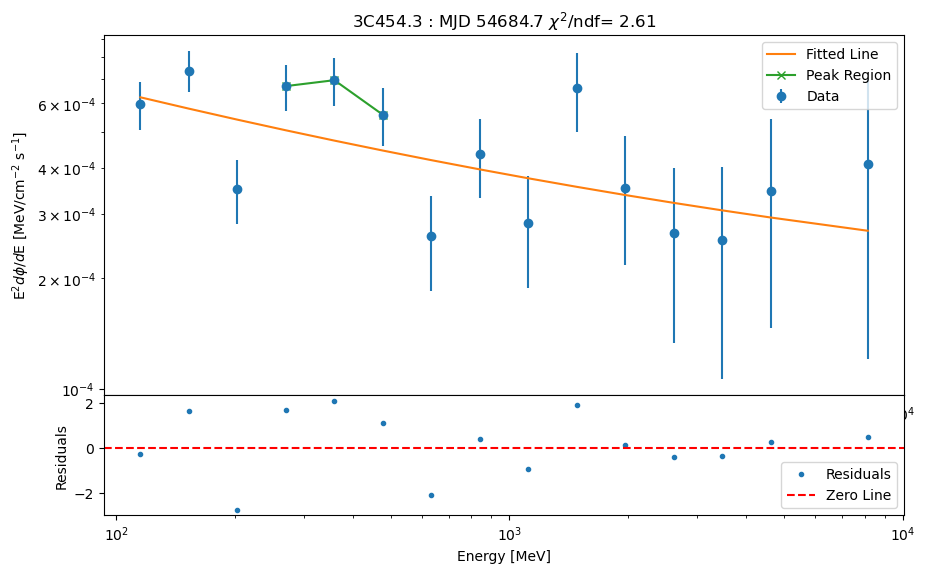

amplitude: 0.0002041534643746518 +/- 0.0003653169210760565
x_0: 9.47191309708993 +/- 0.01672645667678776
alpha: -0.3984442386077586 +/- 0.9889914586235821
beta: 0.08009751408724619 +/- 0.1323615979258552
amplitude: 0.0005455154722042304 +/- 0.0008707504795132852
x_0: 9.46861092550031 +/- 0.005601161373972044
alpha: 0.038967102001010806 +/- 0.8715272455014645
beta: 0.03042660823493043 +/- 0.11452945214705652
amplitude: 8.940428867967412e-05 +/- 0.00016191405625380747
x_0: 9.489878218618525 +/- 0.03530844053846301
alpha: -0.8590035718670876 +/- 1.0330588211679674
beta: 0.16217507734168818 +/- 0.14291936390300425
amplitude: 0.0013538750264139427 +/- 0.0019492034494968415
x_0: 9.465841652258298 +/- 0.01313063102637415
alpha: 0.7848375163386825 +/- 0.7525008783446477
beta: -0.08258490108496247 +/- 0.09354910271493297
amplitude: 0.0008550002306663949 +/- 0.0007336249387959972
x_0: 9.465786685330533 +/- 0.0018885897789215475
alpha: 0.4066042759601662 +/- 0.4626726574288072
beta: -0.0193189877

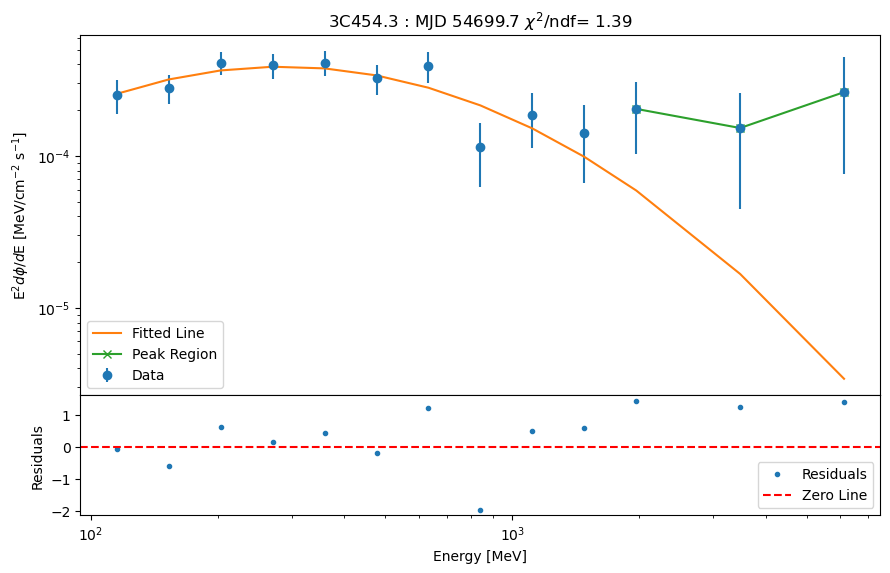

amplitude: 0.015431274327341213 +/- 0.025626072627714238
x_0: 9.490170033465436 +/- 0.037268403427045946
alpha: 1.8713007841226867 +/- 0.9236428635980226
beta: -0.19106349331367026 +/- 0.12215027438924539
amplitude: 0.00459074312418387 +/- 0.004146919501635696
x_0: 9.472026208426419 +/- 0.013448483355967628
alpha: 1.2443801050842491 +/- 0.5021307645512433
beta: -0.12682040417076085 +/- 0.06652551124149744
amplitude: 0.00045414727117047747 +/- 0.00051218937445799
x_0: 9.472866129943517 +/- 0.005431111210606932
alpha: -0.11370582526810885 +/- 0.6032160494987951
beta: 0.04264488919834232 +/- 0.07728749226389742
amplitude: 0.004311487423646653 +/- 0.007852041527115867
x_0: 9.462207286258028 +/- 0.012112132230648108
alpha: 0.8790280683169213 +/- 1.0295610236882142
beta: -0.05564406620287193 +/- 0.13975124789403104
amplitude: 4.288019928002838e-05 +/- 9.844415504877759e-05
x_0: 9.510161257208397 +/- 0.06582099520531848
alpha: -1.4333390968335857 +/- 1.3134337482921083
beta: 0.238294574549356

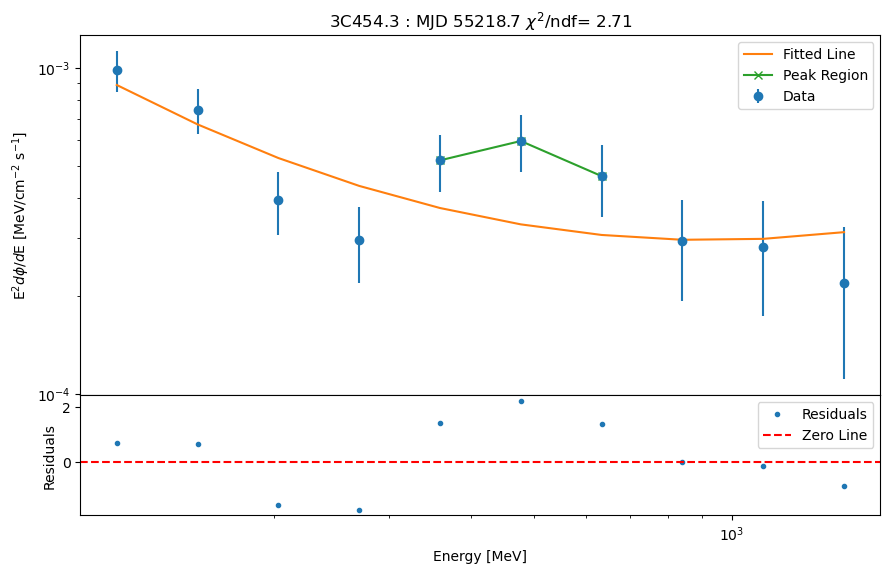

amplitude: 6.734896481717309e-05 +/- 0.00010113979651833066
x_0: 9.499019286964906 +/- 0.028348885795068012
alpha: -1.1459568612587467 +/- 0.7980498667448822
beta: 0.1687154001278498 +/- 0.10232959461423224
amplitude: 0.0007087307143123608 +/- 0.0009940504866727225
x_0: 9.470385148365745 +/- 0.004635917755851888
alpha: 0.03071893612125414 +/- 0.7674099566603025
beta: 0.028605276593951158 +/- 0.10087318296329437
amplitude: 0.0006104496735485061 +/- 0.0013854387412702365
x_0: 9.470210344025066 +/- 0.007369821367396822
alpha: 0.13908274922562178 +/- 1.2719356855073507
beta: 0.02743608673503248 +/- 0.17159376517429406
amplitude: 6.628073206026531e-05 +/- 0.00019496207861587696
x_0: 9.446186679282437 +/- 0.026527581286828424
alpha: -0.6206918600886275 +/- 1.5319086342030819
beta: 0.08178832321271581 +/- 0.19372645354659299
amplitude: 0.00017135362857768855 +/- 0.00017231571948673756
x_0: 9.471056674840016 +/- 0.01124701761003316
alpha: -0.48565156705925966 +/- 0.5560814307538154
beta: 0.095

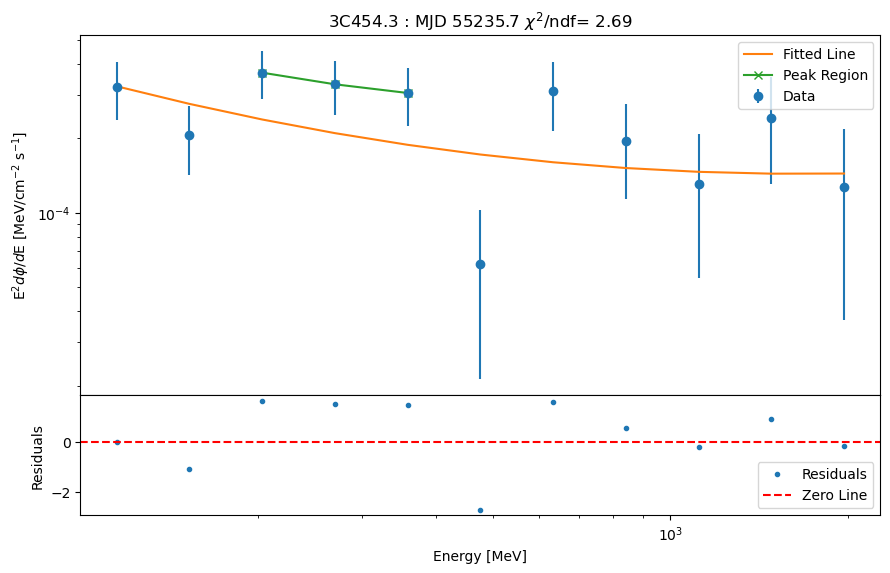

amplitude: 0.0001123239311207213 +/- 0.00024431965970255707
x_0: 9.487937669402216 +/- 0.03039687211395719
alpha: -0.7887963468371914 +/- 1.1755578242746616
beta: 0.12266670363233691 +/- 0.15307547108219907
amplitude: 0.00196385634326146 +/- 0.004042076981619526
x_0: 9.4642657196681 +/- 0.005811026286038508
alpha: 0.6185473063702972 +/- 1.1521173033832965
beta: -0.023865719708572684 +/- 0.15458368864083513
amplitude: 0.006381645886222518 +/- 0.008328428062620599
x_0: 9.471328209903792 +/- 0.017995873224744077
alpha: 1.2346024664026627 +/- 0.7196593167585186
beta: -0.1183752297104341 +/- 0.0947247152091791
amplitude: 6.693869476351803e-05 +/- 0.00014781364091048164
x_0: 9.496380508404837 +/- 0.044898271223101756
alpha: -1.0828544539306857 +/- 1.246701055672145
beta: 0.17099971765998448 +/- 0.17063118900760307
amplitude: 0.0010022797364534566 +/- 0.0017978063346627024
x_0: 9.46747847398081 +/- 0.009833682795461757
alpha: 0.5838688691842648 +/- 0.9840550987073226
beta: -0.0473038221210693

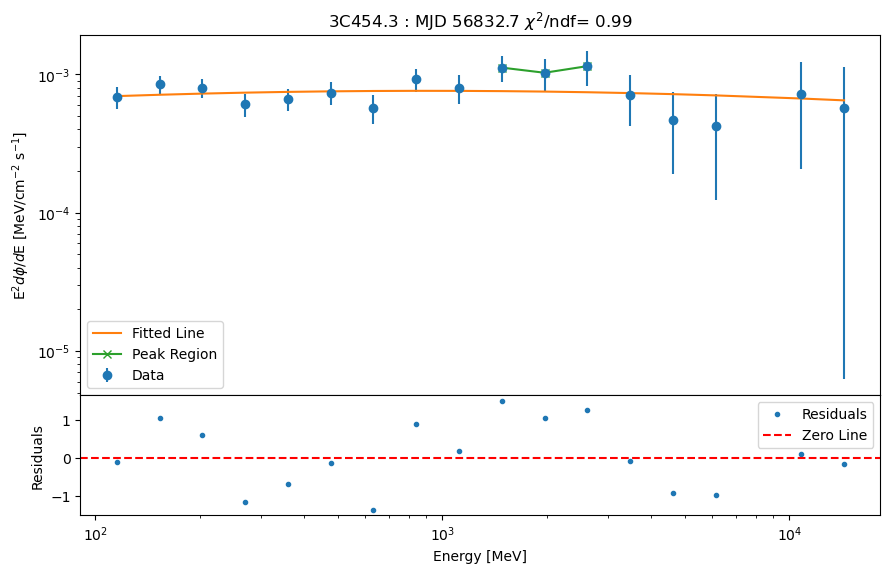

amplitude: 0.0011743017367113378 +/- 0.001100786160751896
x_0: 9.382075243619589 +/- 0.005171242968319425
alpha: 0.3349649780140469 +/- 0.460462980202581
beta: -0.052682370160887025 +/- 0.053487446772053394
amplitude: 8.744097449560403e-05 +/- 5.604831526715383e-05
x_0: 9.488128256454667 +/- 0.006462930517910243
alpha: -0.938853454579634 +/- 0.3160491018122012
beta: 0.09701199713083503 +/- 0.03735274936266611
amplitude: 0.0001744201391964521 +/- 0.00012144247959158078
x_0: 9.471274786197542 +/- 0.003571596838685776
alpha: -0.502789393676766 +/- 0.3383886717759319
beta: 0.049983299339615136 +/- 0.03912871441629255
amplitude: 0.0007723943593340284 +/- 0.0009634243110324237
x_0: 9.463367698805788 +/- 0.00456616147147097
alpha: 0.39141029577698866 +/- 0.6576591377912547
beta: -0.03285210658362 +/- 0.08284250787082625
amplitude: 4.6711796312804185e-06 +/- 1.2178835018171733e-05
x_0: 9.530467574182074 +/- 0.06764290674881326
alpha: -1.9853142111691637 +/- 1.3650807467259514
beta: 0.236128350

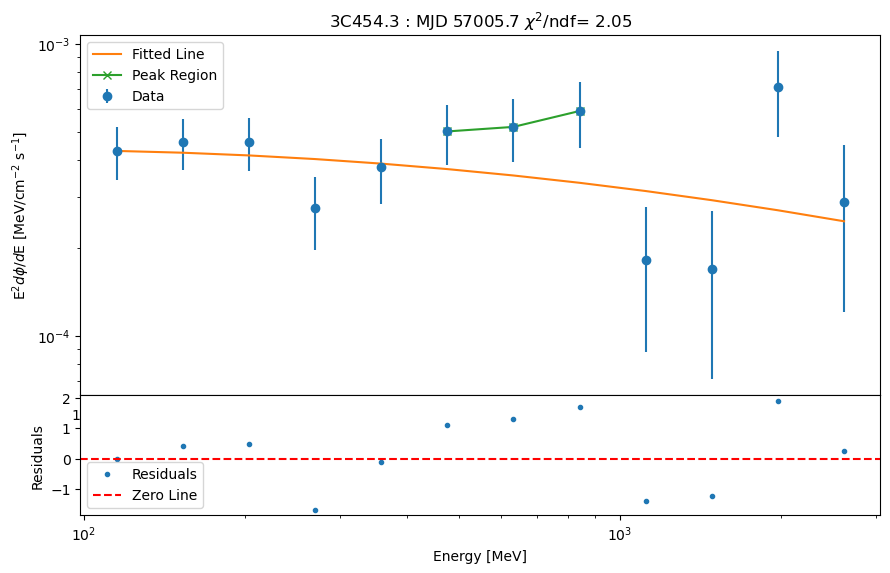

amplitude: 0.00033340773341149427 +/- 0.0006613758210563844
x_0: 9.471266777435599 +/- 0.019378988601069753
alpha: -0.34882141822763923 +/- 1.1260390579523119
beta: 0.08149961281928216 +/- 0.15391125867845015
amplitude: 0.0006939669282884089 +/- 0.0008736944644467501
x_0: 9.439501078857685 +/- 0.010060203140205752
alpha: -0.24949144181426564 +/- 0.6971121287199905
beta: 0.06811181742866394 +/- 0.09271435184806058
amplitude: 0.001296825431497285 +/- 0.0019783039843427903
x_0: 9.46060447368243 +/- 0.0033690090327604845
alpha: 0.40435771452717184 +/- 0.8544098069573574
beta: -0.01865137296001561 +/- 0.11492309126998629
amplitude: 0.00640451174227309 +/- 0.01156535769298363
x_0: 9.486556042548314 +/- 0.0396849848737694
alpha: 1.599602714770552 +/- 0.9815411364516968
beta: -0.1917169297350784 +/- 0.1262757555581296
amplitude: 0.00014799381020215194 +/- 0.000286491884543777
x_0: 9.46126400974208 +/- 0.019622530974845453
alpha: -0.4332597658908165 +/- 1.0851268313644113
beta: 0.08554480567242

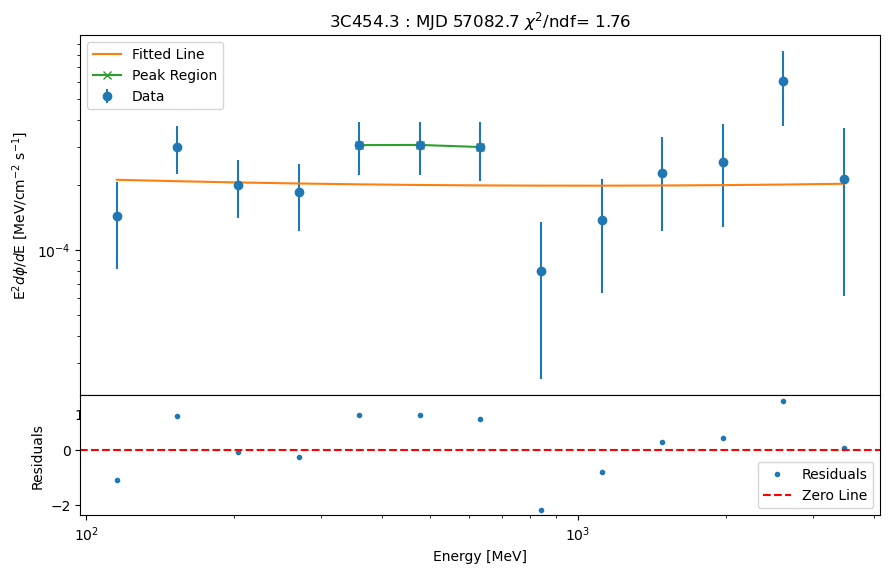

amplitude: 0.0022770966619855048 +/- 0.0036835690178739144
x_0: 9.47435464993175 +/- 0.027372024279764987
alpha: 1.2650178104927834 +/- 0.9014552378897847
beta: -0.14383505636969454 +/- 0.12079123549840756
amplitude: 0.009373632992531893 +/- 0.015709074788764297
x_0: 9.519554020078006 +/- 0.05568116028533304
alpha: 2.245476630256848 +/- 0.9171207141993675
beta: -0.28880146808305374 +/- 0.12011768690030557
amplitude: 2.3657601536961265e-05 +/- 6.0955321167607545e-05
x_0: 9.498635541171696 +/- 0.04767925800826659
alpha: -1.1541509682990962 +/- 1.4170243353925047
beta: 0.15980244013040726 +/- 0.1892752606385417
amplitude: 0.00011481185880625415 +/- 0.000299958075143658
x_0: 9.438977740944134 +/- 0.009361085617864607
alpha: -0.2642971749967711 +/- 1.3348235345707238
beta: 0.03309765952794205 +/- 0.16541170216408888
amplitude: 2.6022763093652228e-05 +/- 7.069845390258569e-05
x_0: 9.502696841159569 +/- 0.0573099577735279
alpha: -1.2530461576053344 +/- 1.482441589136325
beta: 0.18368317389440

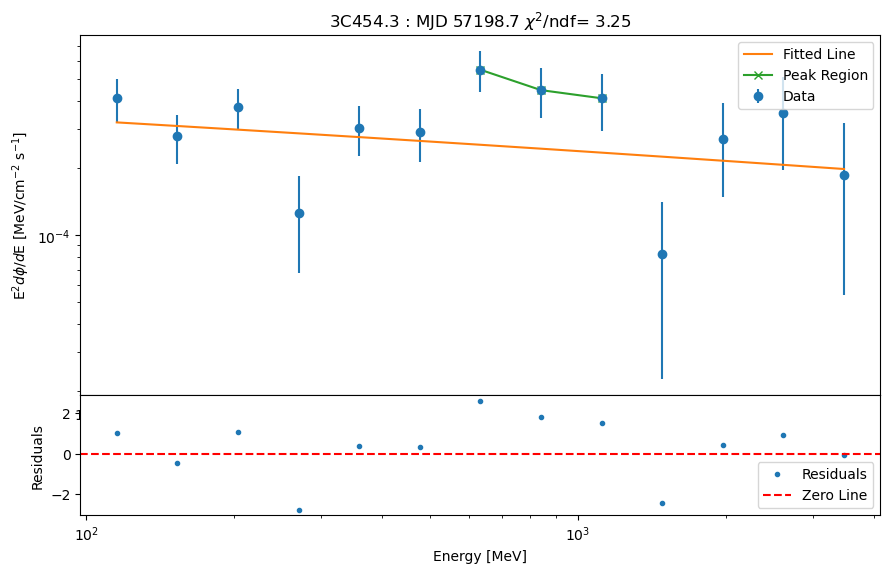

amplitude: 0.0004753187939437567 +/- 0.0009336336170803716
x_0: 9.468218628039732 +/- 0.0011718069867840575
alpha: 0.1473941031042972 +/- 1.038468011636263
beta: -0.0053419362385635745 +/- 0.1310438016703778
amplitude: 0.0031221437070222567 +/- 0.004212182499890788
x_0: 9.468690719875973 +/- 0.012274890609503895
alpha: 1.0311624876849381 +/- 0.7674388453442753
beta: -0.07571525856178699 +/- 0.10478972305095872
amplitude: 0.0017235622224540791 +/- 0.003238205658925696
x_0: 9.464233249844606 +/- 0.005523628614894034
alpha: 0.593359144370844 +/- 1.0446224752678102
beta: -0.02502034136963043 +/- 0.13918777114228423
amplitude: 0.0001754612133272055 +/- 0.00015472706231494065
x_0: 9.494184343936476 +/- 0.01477073083776158
alpha: -1.0029127764179229 +/- 0.4691669515398787
beta: 0.14945214492945522 +/- 0.06011523983272687
amplitude: 0.0003869681332094478 +/- 0.0004661549392318564
x_0: 9.478485083590845 +/- 0.013601917292051202
alpha: -0.5307700581103658 +/- 0.6466971489437906
beta: 0.099679947

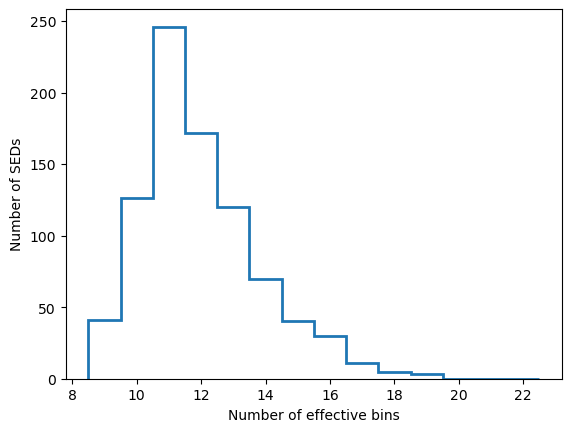

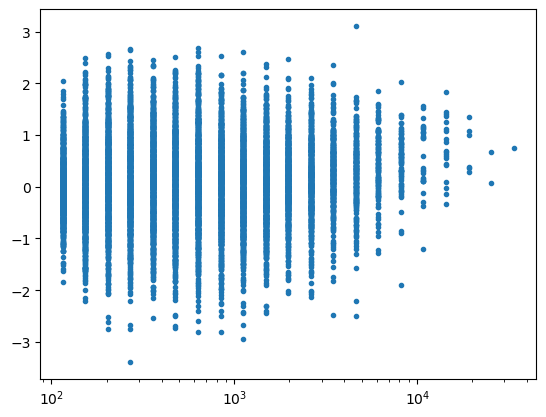

amplitudeIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
 1051.8700862170676
mu 0.13922051145990944
sigma -0.8756530406418314


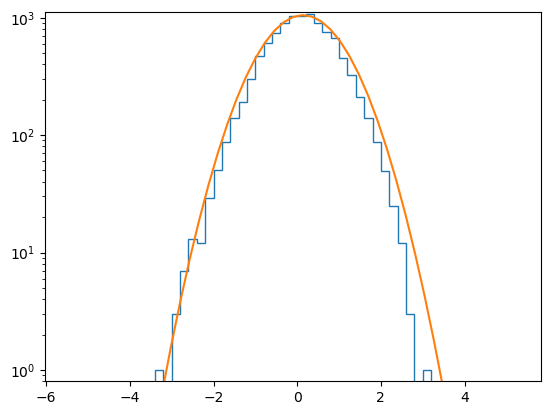

Number of detected peaks: 8
Number of used SEDs: 864
Number of SEDs: 871
Weighted average of the probability from theory:  0.0347214326341633


In [16]:
######################################################################
#   BRIGHTEST OBJECTS
######################################################################
#              assoc name          CLASS
#     ---------------------------- -----
#  1: 3C 454.3                      FSRQ
#  2: Mkn 421                        BLL
#  3: BL Lac                         BLL
#  4: CTA 102                       FSRQ
#  5: 3C 279                        FSRQ
#  6: S5 0716+71                     BLL
#  7: PKS 1424-41                   FSRQ
#  8: PKS 0426-380                   bll
#  9: PKS 0537-441                   BLL
# 10: PKS 2155-304                   bll
# 11: PKS 0454-234                  FSRQ
# 12: PKS 1510-089                  FSRQ
# 13: PKS 1502+106                  FSRQ
# 14: Ton 599                       fsrq
# 15: PKS 0346-27                   fsrq
# 16: 4C +01.02                     fsrq
# 17: 4C +55.17                     fsrq
# 18: 4C +21.35                     FSRQ
# 19: PKS 1830-211                  FSRQ
# 20: PKS 0208-512                  FSRQ
# 21: S5 1044+71                    FSRQ
# 22: 3C 66A                         BLL
# 23: Mkn 501                        BLL
###  1: 3C 454.3         ###  
# eval_spectra('data/3C454.3_allsed_14d_min11.ecsv')  # 2pos, 0neg/264
# eval_spectra('data/3C454.3_allsed_7d_min11.ecsv')   # 3pos, 0neg/208
# eval_spectra('data/3C454.3_allsed_1d_min11.ecsv')   # 8pos, 0neg/556
# eval_spectra('data/3C454.3_allsed_1d_2_min11.ecsv') # 7pos, 0neg/461, several peaks on 56830, sudden drop on 57562
eval_spectra('data/3C454.3_allsed_1d_min11.ecsv')   # 8pos, /864

# show_SED('data/3C454.3_allsed_1d_2_min11.ecsv', 56830, 5) # show SEDs around MJD 56830
# show_SED('data/3C454.3_allsed_1d_2_min11.ecsv', 57562, 5) # show SEDs around MJD 57562

  
###  2: Mkn 421          ### 
# eval_spectra('data/Mrk421_allsed_14d_min11.ecsv')   # 6pos, 1neg/394


###  3: BL Lac           ### 
# eval_spectra('data/BLLac_allsed_14d_min11.ecsv')    # 5pos, 0neg/249　
# -> 3pos, 0neg/294 Almost always sudden drop afterr the peak.
#    3sigma deviations on 59218 (2times), 60604 (2times)
# eval_spectra('data/BLLac_allsed_1d_1_min11.ecsv')    # 2pos, xneg/174
# eval_spectra('data/BLLac_allsed_1d_2_min11.ecsv')    # 3pos, xneg/114


###  4: CTA 102          ### 
# eval_spectra('data/CTA102_allsed_14d_min11.ecsv')   # 5pos, 1neg/180, too low in lowestE on 57790
############## around the strange SED day          ###################
# show_SED('data/CTA102_allsed_14d_min11.ecsv', 57790, 20) # show SEDs around MJD 57790
# show_SED('data/CTA102_allsed_1d_2_min11.ecsv', 57790, 8) # show SEDs around MJD 57790
# show_SED('data/CTA102_allsed_7d_min11.ecsv', 57790, 15) # show SEDs around MJD 57790
############## around the Fig1 in Sahakyan 2020    ###################
# https://www.aanda.org/articles/aa/pdf/2020/03/aa36715-19.pdf
# 57740
# show_SED('data/CTA102_allsed_7d_min11.ecsv', 57740, 5) # show SEDs around MJD 57790
# show_SED('data/CTA102_allsed_1d_2_min11.ecsv', 57740, 5) # show SEDs around MJD 57790

######################################################################
# eval_spectra('data/CTA102_allsed_7d_min11.ecsv')   # 3pos, neg/226
# eval_spectra('data/CTA102_allsed_1d_2_min11.ecsv')  # 4pos, neg/255, three cliffs on 57778, 3sigma peak at 4th bin on 57741
# eval_spectra('data/CTA102_allsed_1d_3_min11.ecsv')  # 1pos, neg/91,

###  5: 3C 279           ### 
# eval_spectra('data/3C279_allsed_14d_min11.ecsv')    
# -> 6pos, 0neg/260, 
#   3sigma peak at 2nd bin on 54794
# eval_spectra('data/3C279_allsed_1d_1_min11.ecsv')    
# -> 1pos, xneg/46, 
# eval_spectra('data/3C279_allsed_1d_2_min11.ecsv')    
# -> 1pos, xneg/183, 

###  6: S5 0716+71       ### 
# eval_spectra('data/S50716+71_allsed_14d_min11.ecsv')    # 4pos, 0neg/278 Almost always sudden drop afterr the peak.

###  7: PKS 1424-41      ### 
# eval_spectra('data/PKS1424-41_allsed_14d_min11.ecsv')    # 3pos, 0neg/297 Mostly sudden drop after the peak.
#   3sigma peak 55382, 58322

###  8: PKS 0426-380     ### 
# eval_spectra('data/PKS0426-380_allsed_14d_min11.ecsv')    # 3pos, /183

###  9: PKS 0537-441     ### 
# eval_spectra('data/PKS0537-441_allsed_14d_min11.ecsv')    # 2pos, /220
#   3sigma peak 58798, 59064

### 10: PKS 2155-304     ### 
# eval_spectra('data/PKS2155-304_allsed_14d_min11.ecsv')   # 3pos, /134

### 11: PKS 0454-234     ### 
# eval_spectra('data/PKS0454-234_allsed_14d_min11.ecsv')    # 2pos, /236

### 12: PKS 1510-089     ### 
# eval_spectra('data/PKS1510-089_allsed_14d_min11.ecsv') # 2pos, 0neg/214
#   3sigma peak 58098

### 13: PKS 1502+106     ### 
# eval_spectra('data/PKS1502+106_allsed_14d_min11.ecsv')    # 0pos, /147

### 14: Ton 599          ### 
# eval_spectra('data/Ton599_allsed_14d_min11.ecsv')    # 2pos, /184

### 15: PKS 0346-27      ### 
# eval_spectra('data/PKS0346-27_allsed_14d_min11.ecsv')    # 2pos, /110

### 16: 4C +01.02        ### 
# eval_spectra('data/4C+01.02_allsed_14d_min11.ecsv')    # 1pos, / 155

### 17: 4C +55.17        ### 
# eval_spectra('data/4C+55.17_allsed_14d_min11.ecsv')    # 0pos, / 37

### 18: 4C +21.35        ### 
# eval_spectra('data/4C+21.35_allsed_14d_min11.ecsv')    # 0pos, / 101

### 19: PKS 1830-211     ### 
# eval_spectra('data/PKS1830-211_allsed_14d_min11.ecsv')    # 1pos, / 117
# eval_spectra('data/PKS1830-211_allsed_1d_min11.ecsv')    # 3pos, / 170
# eval_spectra('data/PKS1830-211_allsed_1d_1_min11.ecsv')    # 3pos, / 168



### 20: PKS 0208-512     ### 
# eval_spectra('data/PKS0208-512_allsed_14d_min11.ecsv')    # 1pos, / 93		

### 21: S5 1044+71       ### 
### 22: 3C 66A           ### 
### 23: Mkn 501          ###


######################################################################
#   ELSE
######################################################################
### The QPO search object
# eval_spectra('data/S20109+22_allsed_14d_min11.ecsv') # 0/50

### One day flare ###
# eval_spectra('data/GB6J1040+0617_allsed_14d_min11.ecsv')
# show_SED('data/GB6J1040+0617_allsed_14d_min11.ecsv', 56902, 5) # show SEDs around MJD 56901

# show_SED('data/GB6J1040+0617_allsed_1h_min5.ecsv', 56902, 5) # show SEDs around MJD 56901
# show_SED('data/GB6J1040+0617_allsed_2h_min5.ecsv', 56902, 5) # show SEDs around MJD 56901
# show_SED('data/GB6J1040+0617_allsed_10min_min11.ecsv', 56902, 5) # show SEDs around MJD 56901
# show_SED('data/GB6J1040+0617_allsed_2min_min5.ecsv', 56902, 5) # show SEDs around MJD 56901

# show_SED('data/3C454.3_allsed_1d_min11.ecsv', 55167, 2) # https://www.nasa.gov/science-research/fermi-sees-brightest-ever-blazar-flare/
# 

# show_SED('data/4C+55.17_allsed_14d_min11.ecsv',59610,10)